## Acknowledgments
This practical is primarily based off the [CLIP tutorial by Moein Shariatnia](https://colab.research.google.com/drive/1hYHb0FTdKQCXZs3qCwVZnSuVGrZU2Z1w?usp=sharing).

#


This week we will be covering Multimodal Deep Learning. Large pre-trained
multimodal models are becoming incredibly popular due to their generalisation
capabilities and wide range of applications. Architectures such as CLIP and
DALL-E are the foundation for the expressive capabilities of GPT-4 and LLaMA.

In this notebook, we will cover the basics of what's required to train
multimodal models, with a focus on the CLIP architecture. We will first explore
feature fusion approaches for downstream tasks involving two modalities, with a
mid fusion and late fusion method. We will
then introduce the CLIP architecture, and create a small CLIP model with an
image and text encoder that have already been pre-trained on separate datasets.
You will then train this CLIP model on the provided dataset, and visualise
the strength of the image-text feature matching. Finally, we will evaluate the
model performance on a zero-shot classification task, where no fine-tuning is
done for the downstream task.

## Setting up Environment
Firstly some prerequisite package installation. If you are using a local conda environment, you can check that your existing environment has the dependencies listed in environment.yml, or you can simply create a new environment using that file.

If using colab, make sure you change your colab runtime type (drop-down in top right corner) to a GPU-enabled one. Your only option will probably be a T4 GPU runtime unless you happen to have colab premium, but it is plenty for this exercise.

In [ ]:
## Are we on Google Colab?
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

if IN_COLAB:
    !pip install timm
    !pip install transformers
    !pip install gdown

### Importing modules

In [ ]:
import os
import itertools
import random
import json
from typing import Any, Callable, List, Optional, Tuple, Dict
random.seed(42)

import numpy as np
import pandas as pd
from tqdm.autonotebook import tqdm
# from tqdm import tqdm
import matplotlib.pyplot as plt
# import cv2
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset
import torch.nn.functional as F
import timm
# import albumentations as A
import torchvision.transforms as transforms
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizer

/tmp/ipykernel_767216/241642186.py:10: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


### Downloading dataset
The dataset we will be using is a subset of the COCO Captions dataset. The [COCO (Common Objects in Context)](https://cocodataset.org) Captions dataset is a large-scale dataset commonly used for object detection, segmentation, and captioning tasks in computer vision. It contains images of everyday scenes, each annotated with object bounding boxes, object categories, and descriptive captions. The captions provide detailed descriptions of the objects and their relationships within the images, making the COCO dataset valuable for training and evaluating models in various visual understanding tasks. We have curated a selection of images alongside their respective captions and a set of labels intended for classification, with a training and validation set. There are ~24,000 training images available in total, but we will only use 10,000 in this tutorial to speed up training.

**NOTE:** The code below should download the dataset automatically, but if it does not work, then download the dataset from colab and make sure it is extracted to the './coco_single_class' directory.

In [ ]:
# Download Data coco_single_clas to your device

dataset = 'coco_single_class'
media_dir = './media'
if IN_COLAB or not os.path.exists(dataset):
    !gdown --fuzzy --folder https://drive.google.com/drive/
    !tar -xvf ./coco_single_class.tar.gz
if IN_COLAB or not os.path.exists(media_dir):
    # Download images for notebook
    !gdown --fuzzy --folder https://drive.google.com/drive/

## Dataset Class
We will be using the pre-made COCOSingleClassDataset class to load the data from the raw json files. This class is also setup as a PyTorch Dataset, which will make training the model easier later on.

In [ ]:
def keystoint(annot_dict):
    for top_key, top_val in annot_dict.items():
        if top_key in ['annotations', 'class_name_dict']:
            annot_dict[top_key] = {int(k): v for k, v in annot_dict[top_key].items()}
    return annot_dict

class COCOSingleClassDataset(Dataset):
    """
    Torch Dataset for custom COCO split. Contains only images with a single
    class label, and has 5 captions per image.

    Batches return image, label, caption, and optionally tokenised captions.
    """
    def __init__(
        self,
        data_dir: str,
        split: str = 'train2017',
        transforms: Optional[Callable] = None,
        tokenizer: Optional[Callable] = None,
        max_token_length: int = 200,
        max_samples: int = -1,
        max_captions_per_image: int = 5,
    ) -> None:
        """
        Constructs the Dataset object.

        Parameters
        ----------
            data_dir : str
                dataset root directory
            split : str
                coco split to use, must be 'train2017' or 'val2017'
            transforms : Optional[Callable]
                pytorch transforms to apply to the images, typically a transforms.Compose() object or None
            tokenizer : Optional[Callable]
                tokenizer to apply to the captions, expects a HuggingFace tokenizer or None if not tokenizing
            max_token_length: int
                max length of tokens, if using tokenizer
            max_samples: int
                max number of samples to load from dataset, useful for debugging, value of -1 loads all samples
            max_captions_per_image: int
                max number of captions to load per image, set to 1 if evaluating image classification performance
        """
        assert max_captions_per_image <= 5, 'Only 5 captions available per image'
        assert max_captions_per_image > 0, 'Minimum 1 caption per image'
        assert split in ['train2017', 'val2017'], 'Invalid split'

        self.data_dir = data_dir
        self.split = split
        self.img_dir = os.path.join(self.data_dir, self.split)
        self.transforms = transforms
        self.tokenizer = tokenizer
        self.max_token_length = max_token_length
        self.max_samples = max_samples
        self.max_captions_per_image = max_captions_per_image
        self.random_seed = 42

        random.seed(self.random_seed)
        self.load_annotations()
        self.img_ids = self._annot_dict['ids']
        self.annotations = self._annot_dict['annotations']
        self.class_name_dict = self._annot_dict['class_name_dict']
        self.generate_samples()

    def __len__(self) -> int:
        return len(self.df_samples)

    def __getitem__(self, idx: int) -> Dict:
        """
        This function will be called automatically when loading batches from
        the dataloader. Batches are returned as a Dictionary object, with the
        keys:
            image : torch.Tensor[torch.float32]
                tensor of dim [B, C, H, W]
            label : torch.Tensor[torch.uint8]
                classification labels of each item in batch
            caption : str
                original caption, for visualisation or debugging purposes
            input_ids : torch.Tensor[torch.int64]
                if using tokenizer, returns a tensor containing tokenised captions
            attention_mask : torch.Tensor[torch.int64]
                if using tokenizer, returns a tensor containing attention masks for tokens
        """
        sample = self.df_samples.iloc[idx]
        item = {}
        img_id = sample['id']
        img_path = sample['image']
        item['image'] = Image.open(img_path).convert('RGB')
        assert(item['image'].mode == 'RGB'), f"Invalid # channels for img {img_id}"
        if self.transforms is not None:
            item['image'] = self.transforms(item['image'])
        if type(item['image']) is not torch.Tensor:  # ensure image is converted to a Tensor
            temp_transform = transforms.ToTensor()
            item['image'] = temp_transform(item['image'])
        item['label'] = torch.tensor(sample['label'], dtype=torch.uint8)
        item['caption'] = sample['caption']
        item['input_ids'] = torch.tensor(sample['input_ids'])
        item['attention_mask'] = torch.tensor(sample['attention_mask'])
        return item

    def load_annotations(self) -> None:
        """
        Load annotations from JSON.
        """
        annot_file = os.path.join(
            self.data_dir, 'annotations', f"annotations_{self.split}.json"
        )
        with open(annot_file, "r") as f:
            annot_dict = json.load(f)
        self._annot_dict = keystoint(annot_dict)
        # Only use subset of annots if specified
        if self.max_samples > 0:
            if self.max_samples >= len(self._annot_dict['ids']): # Already less than max_samples available
                return
            ids_kept = sorted(random.sample(self._annot_dict['ids'], self.max_samples))
            self._annot_dict['ids'] = ids_kept
            self._annot_dict['annotations'] = {k: v for k, v in self._annot_dict['annotations'].items() if k in ids_kept}

    def generate_samples(self) -> None:
        """
        Generates dataframe of samples for every img, caption pair. Accessible
        with self.df_samples, useful for manually comparing images and captions.
        """
        print(f'Generating {self.split} samples...')
        samples = []
        captions_all = []
        for idx in tqdm(self._annot_dict['ids']):
            # Get all annotations associated with image
            img_annots = self.annotations[idx]
            img_path = os.path.join(self.img_dir, img_annots['file_name'])
            # Check image is not corrupted
            try:
                _ = Image.open(img_path).convert('RGB')
            except:
                print(f"Skipped corrupted image {img_path}")
                continue
            label = img_annots['category_id']
            captions = img_annots['captions']
            # Only load number of captions specified as samples
            if self.max_captions_per_image < 5:
                captions = captions[:self.max_captions_per_image]
            captions_all.extend(captions)
            # Add all associated captions
            for caption in captions:
                if self.tokenizer is not None:
                    samples.append([idx, img_path, label, caption])
                else:
                    samples.append([idx, img_path, label, caption, None, None])

        # Tokenize captions
        if self.tokenizer is not None:
            encoded_captions = self.tokenizer(
                captions_all, padding=True, truncation=True, max_length=self.max_token_length
            )
            for idx in range(len(samples)):
                samples[idx].append(encoded_captions['input_ids'][idx])
                samples[idx].append(encoded_captions['attention_mask'][idx])
        # Save to df
        self.df_samples = pd.DataFrame(samples, columns=['id','image','label','caption', 'input_ids', 'attention_mask'])

    def get_class_name(self, label: int) -> str:
        """
        Return class label for given class id.

        Parameters
        ----------
            label : int
                class id, stored as the 'label' element in df_samples

        Returns
        -------
            class_name : str
                class name associated with input class id
        """
        class_name = self.class_name_dict[label]
        return class_name

## Some Pre-processing
The function allows us to grab `df_samples`, which is a Pandas dataframe containing image/caption/label training samples.

In [ ]:
if dataset == 'coco_single_class':
  data_path = "./coco_single_class"
  COCO_dataset_preview = COCOSingleClassDataset(data_dir=data_path,
                                                split='val2017',
                                                transforms=None)

img_ids = COCO_dataset_preview.img_ids
annotations = COCO_dataset_preview.annotations
img_dir = COCO_dataset_preview.img_dir
df_samples = COCO_dataset_preview.df_samples
# Print a data sample
sample = df_samples.iloc[100]
print(sample)
# The 'get_class_name' function of the dataset will get the class name associated with the category_id
get_class_name = COCO_dataset_preview.get_class_name
print(f"\nClass: {sample['label']} = {get_class_name(sample['label'])}")

Generating val2017 samples...


  0%|          | 0/1025 [00:00<?, ?it/s]

id                                                       15746
image             ./coco_single_class/val2017/000000015746.jpg
label                                                       11
caption            A fire hydrant is standing amid some grass.
input_ids                                                 None
attention_mask                                            None
Name: 100, dtype: object

Class: 11 = fire hydrant


This is what the list of samples look like. We have about 120,000 training samples.
Notice how each image has 5 associated captions.

In [ ]:
df_samples

,id,image,label,caption,input_ids,attention_mask
0,285,./coco_single_class/val2017/000000000285.jpg,23,A big burly grizzly bear is show with grass in...,None,None
1,285,./coco_single_class/val2017/000000000285.jpg,23,The large brown bear has a black nose.,None,None
2,285,./coco_single_class/val2017/000000000285.jpg,23,Closeup of a brown bear sitting in a grassy area.,None,None
3,285,./coco_single_class/val2017/000000000285.jpg,23,A large bear that is sitting on grass.,None,None
4,285,./coco_single_class/val2017/000000000285.jpg,23,A close up picture of a brown bear's face.,None,None
...,...,...,...,...,...,...
5120,581781,./coco_single_class/val2017/000000581781.jpg,52,"A store display filled with ripe, unripe banan...",None,None
5121,581781,./coco_single_class/val2017/000000581781.jpg,52,A group of bananas surround a small display of...,None,None
5122,581781,./coco_single_class/val2017/000000581781.jpg,52,"A fruit stand with plantains, kiwis, and banan...",None,None
5123,581781,./coco_single_class/val2017/000000581781.jpg,52,"A fruit stand that has bananas, papaya, and pl...",None,None


And lets visualise some images with their associated captions.

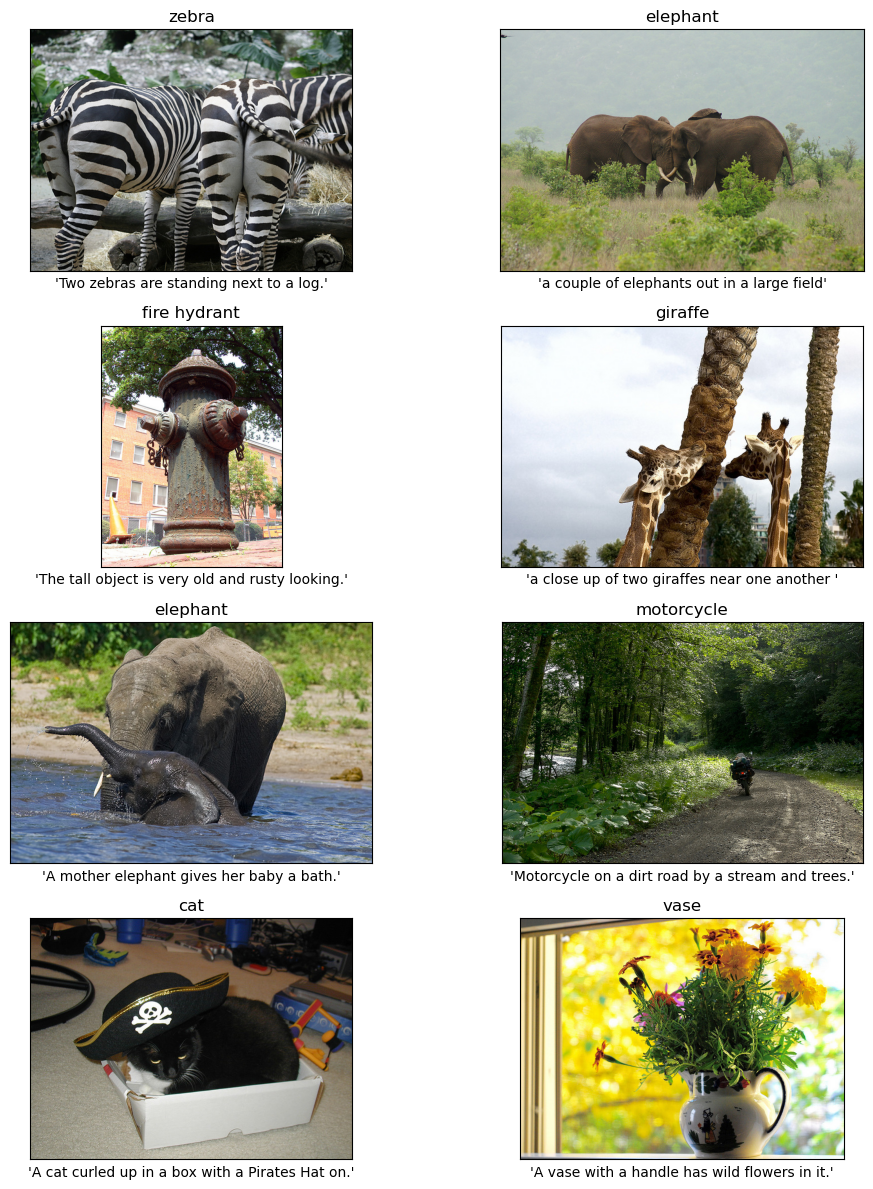

In [ ]:
fig = plt.figure(figsize=(14,12))
example_ids = random.sample(list(range(len(df_samples))), 8)

for idx, id in enumerate(example_ids):
    ax = fig.add_subplot(len(example_ids)//2,2,idx+1)
    sample = df_samples.iloc[id]
    img_path = sample['image']
    image = np.array(Image.open((img_path)).convert('RGB'))
    label_id = sample['label']
    label_str = COCO_dataset_preview.get_class_name(label_id)
    caption = sample['caption']

    ax.imshow(image)
    ax.set_title(label_str)
    ax.set_xlabel(f"'{caption}'")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()

Notice how the images are somewhat noisy and contain multiple objects in the scene.
This is one of the challenges of this dataset.

The images are also different
sizes, which means the model will need some pre-processing to handle variable
input sizes.

## Config
Below is a CFG class to store all model hyperparameters.

In [ ]:
class CFG:
    debug = False
    # image_path = image_path
    # captions_path = captions_path
    max_samples = 10000 # max number of dataset samples to load (-1 for all samples)
    batch_size = 64
    num_workers = 2
    head_lr = 1e-3
    image_encoder_lr = 1e-4
    text_encoder_lr = 1e-5
    weight_decay = 1e-3
    patience = 1
    factor = 0.8
    epochs = 1  # you can train for more epochs if you have the time and want to see better performance
    random_seed = 42
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = 80

    model_name = 'tiny_vit_21m_224.dist_in22k_ft_in1k'
    image_embedding = 576
    text_encoder_model = "distilbert-base-uncased"
    text_embedding = 768
    text_tokenizer = "distilbert-base-uncased"
    max_token_length = 200

    pretrained = True # for both image encoder and text encoder
    trainable = True # for both image encoder and text encoder
    temperature = 1.0 # this is a learnable parameter in CLIP, but we ignore that for this demo

    # image size
    size = 224

    # for projection head; used for both image and text encoders
    num_projection_layers = 1
    projection_dim = 256
    dropout = 0.1

## Utils
Simple utils for tracking metrics and getting learning rate from optimizer.

In [ ]:
class AvgMeter:
    def __init__(self, name="Metric"):
        self.name = name
        self.reset()

    def reset(self):
        self.avg, self.sum, self.count = [0] * 3

    def update(self, val, count=1):
        self.count += count
        self.sum += val * count
        self.avg = self.sum / self.count

    def __repr__(self):
        text = f"{self.name}: {self.avg:.4f}"
        return text

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

## Encoders
For many multimodal models, you first need to encode features for each modality
you are using.

In our case, we are interested in the image and text modalities, so we will
choose two suitable encoders, but the same approach can be applied to pretty
much any modalities you wanted to train a model on, e.g. lidar, audio, hyperspectral.

### Image Encoder

The image encoder code is straight forward. PyTorch Image Models library (timm) makes it easy to implement many different pre-trained image models such as ResNets and ViTs. Here we will use a TinyViT-21m pre-trained on ImageNet as our image encoder (as opposed to full-sized ViT or ResNet)

This network encodes each image to a fixed size vector with the size of the model's output channels (in the case of TinyViT-21m the vector size will be **576**). This is the output after the `nn.AdaptiveAvgPool2d()` layer in TinyViT.

In [ ]:
class ImageEncoder(nn.Module):
    """
    Encode images to a fixed size vector
    """

    def __init__(
        self, model_name=CFG.model_name, pretrained=CFG.pretrained, trainable=CFG.trainable
    ):
        super().__init__()
        self.model = timm.create_model(
            model_name, pretrained, num_classes=0, global_pool="avg"
        )
        for p in self.model.parameters():  # ensure weights are not frozen
            p.requires_grad = trainable

    def forward(self, x):
        return self.model(x)

### Text Encoder

For text, a pre-trained DistilBERT is used as the text encoder. Like its bigger brother BERT, two special tokens will be added to the actual input tokens: **CLS** and **SEP** which mark the start and end of a sentence. To grab the whole representation of a sentence (as the related BERT and DistilBERT papers point out) we use the final representations of the CLS token and we hope that this representation captures the overall meaning of the sentence. By doing this, it is similar to what we did to images when converting them into a fixed size vector.

In the case of DistilBERT (and also BERT) the output hidden representation for each token is a vector with size **768**. So, the whole caption will be encoded in the CLS token representation whose size is 768.

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, model_name=CFG.text_encoder_model, pretrained=CFG.pretrained, trainable=CFG.trainable):
        super().__init__()
        if pretrained:
            self.model = DistilBertModel.from_pretrained(model_name)
        else:
            self.model = DistilBertModel(config=DistilBertConfig())

        for p in self.model.parameters():
            p.requires_grad = trainable

        # we are using the CLS token hidden representation as the sentence's embedding
        self.target_token_idx = 0

    def forward(self, input_ids, attention_mask):
        output = self.model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = output.last_hidden_state
        # Return only the CLS token final hidden representation
        return last_hidden_state[:, self.target_token_idx, :]

## Feature Fusion
But how do we train a model on two or more modalities at the same time?
Let's say you wanted to train a model to do sentiment analysis on associated
images and text, e.g. you want to classify a meme as hateful or not hateful
(the [HatefulMemes](https://ai.meta.com/tools/hatefulmemes/) dataset may be of interest).
How do you merge related information from these different modalities?
Before implementing CLIP, we will look at some feature fusion examples.

One of the simplest ways to do this is with Feature Fusion. Fusion can generally
be split into three categories: early, mid/hybrid, and late fusion.

In early fusion, raw data from each modality is processed and passed to a single encoder.
We will not cover those here for the sake of time, but
([Meta-Transformer](https://arxiv.org/pdf/2307.10802.pdf) is an interesting read
if you're curious). Note that these generally require large pre-training datasets
to learn effective relations between modalities.

In mid fusion, you fuse unimodal features from separate encoders into a
multimodal feature before the final classification head. There are many
approaches to doing this, but the simplest approach is concatenating the
features of each modality.

Late fusion is the other most common approach. Instead of combining features before
a classification head, you instead integrate them after each of the modalities
has made a decision. Again, there are more advanced techniques for this such as
voting schemes and weight-based approaches, but the simplest approach is to
average the classification outputs.

### Mid Fusion
Below is a pseudocode implementation of Mid Fusion for image-caption classification, using feature concatenation.

Note that multimodal classification becomes trivial when your dataset often contains the class
names in the text captions, as in COCO, but this is just a demonstration of the concept.
A more interesting image-text classification dataset would be UPMC Food-101, or MM-IMDb.

In [ ]:
class MidFusionModel(nn.Module):
    def __init__(
        self,
        image_embedding_size=CFG.image_embedding,
        text_embedding_size=CFG.text_embedding,
        num_classes=CFG.num_classes
    ):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        in_feat = image_embedding_size + text_embedding_size
        # Linear classifier, input is concatenated features from each modality
        self.classifier = nn.Linear(in_feat, num_classes)

    def forward(self, batch):
        # Getting Image and Text Features
        image_features = self.image_encoder(batch["image"])
        text_features = self.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )

        # NOTE that a linear projection can be used before concatenating features,
        # to bring the distributions of each closer together

        # Concatenate features to create multimodal embedding
        joint_embeddings = torch.cat((image_features, text_features), 1)

        # Use joint embeddings for some downstream task (classification here)
        logits = self.classifier(joint_embeddings)

        # Do a suitable loss function (cross entropy loss for classification)
        loss = nn.CrossEntropyLoss(logits, batch["labels"])

        return loss.mean()

### Late Fusion
Below is a pseudocode implementation of Late Fusion for classification, with a logit averaging approach.

In [ ]:
class LateFusionModel(nn.Module):
    def __init__(
        self,
        image_embedding_size=CFG.image_embedding,
        text_embedding_size=CFG.text_embedding,
        num_classes=CFG.num_classes
    ):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        # Linear classifier for each modality
        self.image_classifier = nn.Linear(image_embedding_size, num_classes)
        self.text_classifier = nn.Linear(text_embedding_size, num_classes)

    def forward(self, batch):
        # Getting Image and Text Features
        image_features = self.image_encoder(batch["image"])
        text_features = self.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )

        # Get logits for each modality
        image_logits = self.image_classifier(image_features)
        text_logits = self.text_classifier(text_features)

        # Average the logits
        logits = (image_logits + text_logits) / 2

        # Do a suitable loss function (cross entropy loss for classification)
        loss = nn.CrossEntropyLoss(logits, batch["labels"])

        return loss.mean()

## Projection Head


The above approaches are very simple ways to fuse modalities. However,
particularly for mid fusion, it is often not best to combine features directly
after feature encoding. It is common to first project the features of each
modality into a **multimodal embedding space** with the same dimensions for both
images and captions. This makes it easier for the model to compare them and push
apart the unrelated image and captions (negatives) while pulling together those
that match (positives). This is also a core concept behind multimodal contrastive
learning, or feature alignment in this case, which we will discuss shortly in the
CLIP implementation. So, the following code will bring the 576 and 768 dimensional
vectors into a 256 (*projection_dim*) dimensional world, where they will
hopefully be easier to compare.

For understanding the details of this part you can refer to the CLIP paper,
but in essence, a series of linear layers with GELU activation projects the
embedding vectors to the desired size, with added dropout, residual connection,
and layer norm for training stability.

In [ ]:
class ProjectionHead(nn.Module):
    def __init__(
        self,
        embedding_dim,
        projection_dim=CFG.projection_dim,
        dropout=CFG.dropout
    ):
        super().__init__()
        self.projection = nn.Linear(embedding_dim, projection_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(projection_dim, projection_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(projection_dim)

    def forward(self, x):
        projected = self.projection(x)
        x = self.gelu(projected)
        x = self.fc(x)
        x = self.dropout(x)
        x = x + projected
        x = self.layer_norm(x)
        return x

## What is CLIP?
Now for the fun part. Instead of training a multimodal for a specific downstream
task, what if we instead leveraged the inherent similarities between two modalities
to learn strong general features that can be useful for many downstream tasks?
This is the core motivation behind **Contrastive Language-Image Pre-training**
, or **CLIP**, first introduced in the paper
[Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020).

In a nutshell, this model learns the relationship between a whole sentence and the image it describes. When the model is trained, given an input sentence, it will be able to retrieve the most relevant images corresponding to that sentence. The important thing here is that it is trained on full sentences instead of single classes like car, dog, etc. The intuition is that when trained on whole sentences, the model can leverage the power of LLMs to identify the relationship between individual words and different aspects of an image, e.g. color, shape, subject, background, etc.

The authors also show that when this model is trained on a huge dataset of images and corresponding captions, it can act as a zero-shot classifier too, where it can classify images without ever being trained on a specific set of classes. In the paper, the CLIP model trained with this strategy classifies ImageNet better than some SOTA models trained on ImageNet itself, which are optimized solely for the task of classification.

The general structure of CLIP is seen below:

<img src="https://raw.githubusercontent.com/mlfoundations/open_clip/main/docs/CLIP.png" alt="CLIP Overview" width="800" height="auto">

So how does it do this? CLIP follows a **feature alignment** approach. During pre-training,
an image and text feature extractor are jointly trained to predict the correct
pairings of images and texts within a batch. Quite simply, the model learns
features for each modality that maximise feature similarity of matched input pairs.

The key to this approach is a diverse pre-training dataset, ideally with images
that contain multiple objects in difference contexts, and descriptive captions
that mention how those objects relate to each other and the scene.

We use the COCO subset as it is small enough for us to train on, while still
having suitable data diversity.

We will now implement a simple version of CLIP to demonstrate its power.

#### Check the cell below for the rest of the explanation

In [ ]:
class CLIPModel(nn.Module):
    def __init__(
        self,
        temperature=CFG.temperature,
        image_embedding=CFG.image_embedding,
        text_embedding=CFG.text_embedding,
    ):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        self.image_projection = ProjectionHead(embedding_dim=image_embedding)
        self.text_projection = ProjectionHead(embedding_dim=text_embedding)
        self.temperature = temperature

    def loss_fn(self, image_embeddings, text_embeddings):
        # Compute logits for image and text embeddings
        ### NOTE how cross attention is computed here ###
        image_logits = image_embeddings @ text_embeddings.T * self.temperature
        text_logits = text_embeddings @ image_embeddings.T * self.temperature
        # Compute targets (knowing that labels are aligned)
        num_logits = image_logits.shape[0]
        targets = torch.arange(num_logits, device=image_embeddings.device, dtype=torch.long)
        # Compute cross entropy for each, maximising cosine similarity along diagonal
        image_loss = F.cross_entropy(image_logits, targets, reduction='none')
        text_loss = F.cross_entropy(text_logits, targets, reduction='none')
        loss =  (image_loss + text_loss) / 2.0 # shape: (batch_size)
        return loss.mean()

    def forward(self, batch):
        # Getting Image and Text Features
        image_features = self.image_encoder(batch["image"])
        text_features = self.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )
        ### NOTE: Projection and L2 normalisation lines can be left out in future ###
        # Getting Image and Text Embeddings (with same dimension)
        image_embeddings = self.image_projection(image_features)
        text_embeddings = self.text_projection(text_features)

        # L2 normalise before computing cosine similarity
        image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)
        text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)

        loss = self.loss_fn(image_embeddings_n, text_embeddings_n)

        return loss

Here we use the previous modules that we built to implement the main model. The `__init__` function is self-explanatory, we initalise the encoders and projection heads for each modality. In the forward function, we first encode the images and captions separately into fixed size vectors (with different dimensionalities). After that, using separate projection modules we project them to the multimodal embedding space. Here the encodings will become a similar shape (256 in our case). After that we compute the loss to determine how similar our image and text embeddings are, but how does CLIP's loss do this?

Recapping from what you've learnt in Linear Algebra, one common way to measure if two vectors are similar is to calculate their **cosine similarity**, which is computed as the dot product of l2 normalised vectors. A cosine similarity value near 1 means the two vectors are similar, while a value near -1 means the two vectors are opposite. Cosine similarity is calculated with:

$$\text{cosine similarity} = \frac{A\cdot B}{\|A\|\|B\|}$$

Here, we have `image_embeddings`, a matrix with shape `(batch_size, 256)` and `text_embeddings` with shape `(batch_size, 256)`. These are firstly l2 normalised along each row. To determine the similarity between each embedding pair, we can simply use the dot product (@ operator in PyTorch does the dot product or matrix multiplication in this case). To be able to multiply these two matrices together, we transpose the second one. This returns a matrix with shape `(batch_size, batch_size)` that we call logits, which has the pairwise cosine similarities. We do this with each modality and get logits for our image and text embeddings, i.e. how similar they are to the corresponding feature in the other modality.

Now that we have our logits, we need targets to compute a loss. Let's consider what we hope that this model learns: **we want it to learn "similar representations" for a given image and the caption describing it.** Meaning that, for a given image or the text describing it, we ideally want it to produce the same 256-sized vectors for both. Let's think now: if this happens, what would the logits matrix be like? Let's see with a simple example.

In [ ]:
# A simple Example, with identical embeddings
batch_size = 4
dim = 256
embeddings = torch.randn(batch_size, dim)
embeddings = F.normalize(embeddings, p=2, dim=-1)  # L2 normalise
logits = embeddings @ embeddings.T
print(logits)

So logits, in the best case, will have 1s along the diagonal, and low values everywhere else. This is the purpose of the `targets` matrix in the loss function. Now that we've got our targets matrix, cross entropy is used to calculate the loss for each modality, which is then averaged to produce the final loss value.

This loss is an example of a contrastive loss function, as the model is incentivised to maximise the embedding similarity of positives, while pushing apart the embeddings of negatives.

An example similarity matrix for a set of inputs and CLIP embeddings can be seen below:

<img src="https://amaarora.github.io/images/cosine_similarity.png" alt="CLIP cosine similarity" width="800" height="auto">

(Credit: [Aman Arora](https://amaarora.github.io/posts/2023-03-11_Understanding_CLIP_part_2.html), who has a good explanation of the CLIP loss function if you're interested)

One final thing to note is that Temperature is a fixed parameter equal to 1.0 in our case, so it does not make a difference on the loss function. You can play with it and see what difference it makes, or read the paper to understand it fully. In short, it is a scalar learnt during training that controls the range of logits in the softmax, which helps to prevent training instability due to the logits being too large or small.

### Loss playground
Use the skeleton below to experiment with CLIP's loss. Similar to the code block
above, generate some dummy embeddings, and pass them through the loss function.
You should expect a loss approaching 0 for similar embeddings, and a larger loss
for dissimilar embeddings.

In [ ]:
CLIP_test = CLIPModel()
image_feat = None
# NOTE: Generate some dummy features:
image_feat = torch.randn(16, 256)
text_feat_similar = image_feat
text_feat_dissimilar = torch.randn(16, 256)
# Pass through the loss function with the below line
loss_similar = CLIP_test.loss_fn(image_feat, text_feat_similar)
print(loss_similar)
loss_dissimilar = CLIP_test.loss_fn(image_feat, text_feat_dissimilar)
print(loss_dissimilar)

#-----------------------YOUR CODE BELOW------------------------#


## Train
Here are some funtions to help us load training and validation dataloaders for our model, and then train and evaluate our model on those. There's not much going on here; just a simple training loop and utility functions.

**Your Turn:** No data augmentations are used other than resizing and normalizing in this example, which can increase the likelihood of model overfitting. Try adding some suitable augmentations here to improve the model's training.

In [ ]:
def get_transforms(mode="train"):
    if mode == "train":
        return transforms.Compose([
            transforms.Resize(size=(CFG.size, CFG.size), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
            # Add suitable data augmentations here. Check out
            # https://pytorch.org/vision/0.17/transforms.html#v1-api-reference
            # for some ideas, and for easy implementation.
            #-----------------------YOUR CODE BELOW------------------------#

        ])
    else:
        return transforms.Compose([
            transforms.Resize(size=(CFG.size, CFG.size), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
        ])


def build_loaders(tokenizer, mode, max_captions_per_image=5):
    transforms = get_transforms(mode=mode)
    if mode == 'train':
        split = 'train2017'
    elif mode == 'valid':
        split = 'val2017'
    else:
        raise ValueError('Invalid mode provided')
    dataset = COCOSingleClassDataset(
        data_dir=data_path,
        split=split,
        transforms=transforms,
        tokenizer=tokenizer,
        max_token_length=CFG.max_token_length,
        max_samples=CFG.max_samples,
        max_captions_per_image=max_captions_per_image
    )
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        num_workers=CFG.num_workers,
        shuffle=True if mode == "train" else False,
    )
    return dataloader

Here's a handy function to train our model. There's not much happening here either; just loading the batches, feeding them to the model and stepping the optimizer and lr_scheduler. For tokenization, we are using a DistilBERT pre-trained tokenizer, which will ensure our captions are converted to fixed-length tensors that can be run in PyTorch.

In [ ]:
def train_epoch(model, train_loader, optimizer, lr_scheduler, step):
    loss_meter = AvgMeter()
    tqdm_object = tqdm(train_loader, total=len(train_loader))
    for batch in tqdm_object:
        batch = {k: v.to(CFG.device) for k, v in batch.items() if k != "caption"}
        loss = model(batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step == "batch":
            lr_scheduler.step()

        count = batch["image"].size(0)
        loss_meter.update(loss.item(), count)

        tqdm_object.set_postfix(train_loss=loss_meter.avg, lr=get_lr(optimizer))
    return loss_meter


def valid_epoch(model, valid_loader):
    loss_meter = AvgMeter()

    tqdm_object = tqdm(valid_loader, total=len(valid_loader))
    for batch in tqdm_object:
        batch = {k: v.to(CFG.device) for k, v in batch.items() if k != "caption"}
        loss = model(batch)

        count = batch["image"].size(0)
        loss_meter.update(loss.item(), count)

        tqdm_object.set_postfix(valid_loss=loss_meter.avg)
    return loss_meter


def main(train_loader, valid_loader):
    # train_df, valid_df = make_train_valid_dfs()

    model = CLIPModel().to(CFG.device)
    params = [
        {"params": model.image_encoder.parameters(), "lr": CFG.image_encoder_lr},
        {"params": model.text_encoder.parameters(), "lr": CFG.text_encoder_lr},
        {"params": itertools.chain(
            model.image_projection.parameters(), model.text_projection.parameters()
        ), "lr": CFG.head_lr, "weight_decay": CFG.weight_decay}
    ]
    optimizer = torch.optim.AdamW(params, weight_decay=0.)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=CFG.patience, factor=CFG.factor
    )
    step = "epoch"

    best_loss = float('inf')
    for epoch in range(CFG.epochs):
        print(f"Epoch: {epoch + 1}")
        model.train()
        train_loss = train_epoch(model, train_loader, optimizer, lr_scheduler, step)
        model.eval()
        with torch.no_grad():
            valid_loss = valid_epoch(model, valid_loader)

        if valid_loss.avg < best_loss:
            best_loss = valid_loss.avg
            torch.save(model.state_dict(), "best.pt")
            print("Saved Best Model!")

        lr_scheduler.step(valid_loss.avg)

Running the next cell starts training the model. Put the kernel on GPU mode if it isn't already. Every epoch should take about 15 minutes. It can take a few minutes before training actually starts because we are going to encode all the captions once in the training and validation dataset, so don't be alarmed if it hangs for a while.

If you want to see the best results possible though, leave this running for a couple hours or so before stopping it, but beware that Colab can sometimes timeout free users that train for too long. You can change the desired number of epochs in the CFG class, but one epoch is enough to get decent results.

If you get CUDA out of memory errors or similar, try reducing the batch size in the CFG class until the errors cease.

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained(CFG.text_tokenizer)
train_loader = build_loaders(tokenizer, mode="train")
valid_loader = build_loaders(tokenizer, mode="valid")
main(train_loader, valid_loader)

## Inference

Okay! We are done with pre-training the model. Now, we need to do inference which in our case will be giving the model a piece of text and retrieving the most relevant images from an unseen validation (or test) set.

### Getting Image Embeddings
In this function, we are loading the model that we saved after training, feeding it images in validation set and returning the image_embeddings with shape `(valid_set_size, 256)` and the model itself.

In [ ]:
def get_image_embeddings(model_path, valid_loader):
    model = CLIPModel().to(CFG.device)
    model.load_state_dict(torch.load(model_path, map_location=CFG.device))
    model.eval()

    valid_image_embeddings = []
    print("Getting image embeddings...")
    with torch.no_grad():
        for batch in tqdm(valid_loader):
            image_features = model.image_encoder(batch["image"].to(CFG.device))
            image_embeddings = model.image_projection(image_features)
            valid_image_embeddings.append(image_embeddings)
    return model, torch.cat(valid_image_embeddings)

In [ ]:
model, image_embeddings = get_image_embeddings("best.pt", valid_loader)

### Finding Matches
Now to see if the model can match text to images. This function takes the model, image_embeddings, and a text query, and displays the most relevant images it finds in the validation set. Note the use of cosine similarity once again to determine image and text similarity, followed by a top-k operation to retrieve the k most similar images.

In [ ]:
def find_matches(model, tokenizer, image_embeddings, query, df_samples, n=9):
    image_filenames = df_samples['image']
    encoded_query = tokenizer([query])
    batch = {
        key: torch.tensor(values).to(CFG.device)
        for key, values in encoded_query.items()
    }
    with torch.no_grad():
        text_features = model.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )
        text_embeddings = model.text_projection(text_features)

    image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)
    text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)
    cos_similarity = text_embeddings_n @ image_embeddings_n.T

    values, indices = torch.topk(cos_similarity.squeeze(0), n * 5)
    matches = [image_filenames[int(idx)] for idx in indices[::5]]

    _, axes = plt.subplots(3, 3, figsize=(10, 10))
    for match, ax in zip(matches, axes.flatten()):
        image = np.array(Image.open(match))
        ax.imshow(image)
        ax.axis("off")

    plt.show()

If all went well, you should hopefully see some photos of zebras running on grass. If not, you may need to train for a few more epochs. Feel free to change the query and see what else CLIP has learnt, although note that the COCO single class subset is not all-encompassing, and many queries simply won't exist in the data.

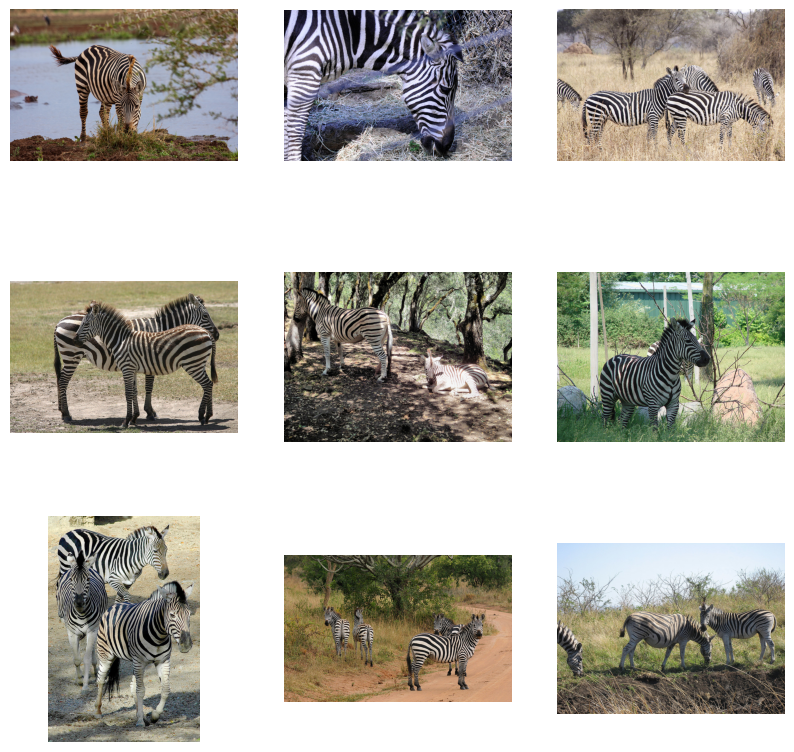

In [ ]:
find_matches(model,
             tokenizer,
             image_embeddings,
             query="zebras running on grass",
             df_samples=valid_loader.dataset.df_samples,
             n=9)

## Zero-Shot Transfer
So how can we use CLIP for tasks other than text-based image retrieval? In the
CLIP paper, the authors demonstrate that CLIP pre-training exhibits strong
generalisation to many unseen datasets and downstream tasks. They demonstrate
impressive results for zero-shot classification, representation learning, and
robustness to distribution shift.

We will now adapt our CLIP model to do zero-shot classification. The key
part of zero-shot classification is the classifier is never trained specifically
to classify images into specific classes. Compare this to the common approach of
linear probing a pre-trained model, where a linear classifier is trained on a
small subset of data using the pre-trained features from the model.

In CLIP zero-shot, classification is done using the feature similarity matching
component. A text embedding for each class is pre-computed, and then for each
image in the test set, the image embedding is compared with the text embeddings
to find the most similar pair, which indicates the selected class.

### CLIP Zero Shot Model
We adapt the existing CLIP model for zero shot by ignoring the sample captions,
and instead computing similarity between image embeddings and the embeddings of
all 80 class labels, which we will precompute in another function.

In [ ]:
class CLIPZeroShotModel(nn.Module):
    def __init__(
        self,
        temperature=CFG.temperature,
        image_embedding=CFG.image_embedding,
        text_embedding=CFG.text_embedding,
    ):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        self.image_projection = ProjectionHead(embedding_dim=image_embedding)
        self.text_projection = ProjectionHead(embedding_dim=text_embedding)
        self.temperature = temperature

    def forward(self, batch):
        # Just getting Image Features, as Text Embeddings are pre-computed
        image_features = self.image_encoder(batch["image"])

        # Getting Image and Text Embeddings (with same dimension)
        image_embeddings = self.image_projection(image_features)

        # L2 normalise
        image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)

        # Compute logits
        logits = image_embeddings_n @ batch["label_embeddings_n"].T * self.temperature

        return logits

### Pre-computing label embeddings
We now need to tokenize and compute embeddings for all the class labels. We could
just use the class label as an input query, but as our model was trained on sentence
captions describing the image, it would be better if we choose a sentence such as
"A photo of a {class}". You can employ some level of prompt engineering to find
a better prompt depending on the context of the image, but this naive approach
will work well enough for most images.

Below we embed all our class labels within this query template, tokenize them all,
and compute the pre-trained model embeddings for all classes. These will be
passed to our altered CLIP model.

In [ ]:
def get_label_embeddings(model, valid_loader, tokenizer, query_template="A photo of a "):
    model.eval()
    print("Getting label embeddings...")
    label_list = list(valid_loader.dataset.class_name_dict.keys()) # use this to get original class idx back
    label_queries = []
    # Generate query sentences, and tokenize them
    for label_id in label_list:
        label_str = valid_loader.dataset.get_class_name(label_id)  # get class name associated with label id
        label_queries.append(f"{query_template}{label_str}.")  # e.g. "A photo of a zebra."
    encoded_queries = tokenizer(
        label_queries, padding=True, truncation=True, max_length=CFG.max_token_length
    )

    # Create batch for queries
    batch = {}
    for key, values in encoded_queries.items():
        batch[key] = torch.tensor(values).to(CFG.device)

    # Get embeddings from model
    with torch.no_grad():
        text_features = model.text_encoder(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )
        label_embeddings = model.text_projection(text_features)
        label_embeddings_n = F.normalize(label_embeddings, p=2, dim=-1)

    return label_embeddings_n, label_list

Below we define an evaluation loop for zero-shot classification using the val
set. We first precompute the label embeddings with the function defined above,
then in a loop, we get the logits from the model, softmax them to make them a
probability distribution, and use argmax to find the predicted class (which will
be the one with the highest probability). We then count the number of correct
retrievals. Accuracy is the reported metric here.

In [ ]:
def zero_shot_eval(model_path, valid_loader, tokenizer):
    model = CLIPZeroShotModel().to(CFG.device)
    model.load_state_dict(torch.load(model_path, map_location=CFG.device))
    model.eval()
    # Pre-compute text embeddings for all classes
    label_embeddings_n, label_list = get_label_embeddings(model, valid_loader, tokenizer, query_template="A photo of a ")
    label_list = np.array(label_list)
    num_success = 0
    print(f"Evaluating...")
    with torch.no_grad():
        tqdm_object = tqdm(valid_loader, total=len(valid_loader))
        for batch in tqdm_object:
            # Add label embeddings to batch, we will ignore regular text embeddings
            batch['label_embeddings_n'] = label_embeddings_n
            batch = {k: v.to(CFG.device) for k, v in batch.items() if k != "caption"}
            # Compute softmax of logits, count highest prob class as model classification
            logits = model(batch)
            probs = F.softmax(logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            pred_id_fix = label_list[pred.cpu().numpy()]
            # Count number of successful classifications
            num_success += np.count_nonzero(pred_id_fix == batch["label"].cpu().numpy())

    # Report accuracy
    accuracy = num_success / len(valid_loader.dataset)
    print(f"Model accuracy: {accuracy:.3f}")

And now we can evaluate zero shot performance! Note that we need to load a separate
dataloader here. We are using the COCO single class validation set, but since we
are not using captions, we only want to evaluate 1 sample per image, to prevent
redundant evaluations.

In [ ]:
# Only load 1 caption per image, so that each image is only evaluated once
valid_loader_zero_shot = build_loaders(tokenizer, mode="valid", max_captions_per_image=1)
zero_shot_eval("best.pt", valid_loader_zero_shot, tokenizer)

Hopefully your accuracy is somewhat high, but if not, then it's an indication
that your model needs to be trained for longer. Keep in mind we are starting
with an image and text encoder that have already been pre-trained on datasets
relatively similar to COCO, so the domain gap is relatively small. In the CLIP
paper, pre-training is done entirely from scratch, but this requires massive
batch sizes and number of epochs, and a suitably massive dataset to properly
train the model.

## Fine-Tuning CLIP with Learnable Prompts
In this example, we have elected to make a relatively small version of CLIP (when compared to the billions of parameters learnt by the real model), and trained on a small dataset of 10k images, compared to the 400 million images in the WIT dataset. As a result, this model is fairly quick to train and would be easy to fine-tune on a new dataset. But what if you wanted to take advantage of the full capabilities of CLIP? If you had the compute power of OpenAI or Google, then this would take a matter of days, but for most people, these models are simply too large to train. Fine-tuning also runs the risk of catastrophic forgetting, where the strong generalisation that CLIP learnt through massive pre-training is diminished, and the risk of overfitting increases.

New research has been pushing in the direction of making CLIP practical to fine-tune, while preventing loss of generalisation. One popular method to do this is prompt learning. In the zero-shot classification setting of the base CLIP model, prompts are typically handcrafted by generating an input sequence like, "a photo of a [CLASS]", to make the class label more similar to the captions CLIP was trained on. However, [Context Optimization (CoOp)](https://arxiv.org/abs/2109.01134) argues that handcrafted prompts may not always provide the best context for CLIP, and instead proposes learnable prompts for the text encoder. These prompts take the form "$[V]_1[V]_2...[V]_M[\mathrm{CLASS}]$", where each $[V]_M$ is a learnable vector with the same dimensionality as the word embeddings. The class token can also be placed in the middle of the prompt to increase flexibility. During fine-tuning, the massive pre-trained parameters of the image and text encoders are frozen, while the prompts remain learnable, allowing CoOp to optimize context tokens to the new dataset, without losing the generalisation performance learnt during training.

<img src="https://minio.cvmart.net/cvmart-community/images/202206/30/0/006C3FgEgy1gv4byc8i00j60j508pac402.jpg" alt="CoOp Diagram" width="800" height="auto">

However, CoOp only learns to optimize these prompts on the text encoder of CLIP, ignoring the image encoder. To amend this, [Multi-modal Prompt Learning (MaPLe)](https://arxiv.org/pdf/2210.03117.pdf) allows the learnable prompts to influence the text and image encoders, and couples the optimization on both by making the image prompts a learnable linear projection of the text prompts. Approaches like [Multimodal Prompting with Missing Modalities for Visual Recognition](https://openaccess.thecvf.com/content/CVPR2023/papers/Lee_Multimodal_Prompting_With_Missing_Modalities_for_Visual_Recognition_CVPR_2023_paper.pdf) even allow for multimodal classification models to stay performant when a modality is missing, simply by learning prompts that are aware of missing modalities.

**Your turn:** As an extension challenge, try alter the above zero-shot classification code to fine-tune on the data by swapping the fixed prompts for learnable prompts similar to CoOp, and see if performance improves.

In [ ]:
# Redefine the Zero Shot class but with learnable tokens (you may want to use nn.Parameter() or similar)
class CLIPZeroShotLearnableTokensModel(nn.Module):
    def __init__(
        self,
        temperature=CFG.temperature,
        image_embedding=CFG.image_embedding,
        text_embedding=CFG.text_embedding,
    ):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        self.image_projection = ProjectionHead(embedding_dim=image_embedding)
        self.text_projection = ProjectionHead(embedding_dim=text_embedding)
        self.temperature = temperature

        #-----------------------YOUR CODE BELOW------------------------#
        ## NOTE: Define learnable parameter here
        self.learnable_prompt = None

    def forward(self, batch):
        # Just getting Image Features, as Text Embeddings are pre-computed
        image_features = self.image_encoder(batch["image"])

        #-----------------------YOUR CODE BELOW------------------------#
        # Pass the class label through here.
        # Note that you may want to edit the zero_shot_eval code to pass all
        # class labels to the batch element, so that the learnable prompts can
        # be applied here. There are a few ways to do this, either in this
        # class, or in a separate class.
        label_embeddings_n = self.learnable_prompt(batch["all_labels"])

        # Getting Image and Text Embeddings (with same dimension)
        image_embeddings = self.image_projection(image_features)

        # L2 normalise
        image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)

        # Compute logits
        logits = image_embeddings_n @ label_embeddings_n.T * self.temperature

        return logits